## COVID-19 Data Analysis in the United States
### Project Introduction

This project analyzes COVID-19 pandemic data across different US states. The dataset includes case counts, population, GDP, and urban population percentage for each state. The goal is to examine the relationships between economic and demographic factors and the severity of the pandemic across different states.

## Step 1: Import Required Libraries

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load and Initial Data Exploration

In [3]:
df = pd.read_csv('covid-merged.csv')

print("First 5 rows of the data:")
df.head()

First 5 rows of the data:


,state,cases,population,gdp,urban
0,Alabama,7068,4903185,230750.10,59.04
1,Alaska,353,731545,54674.70,66.02
2,Arizona,7648,7278717,379018.80,89.81
3,Arkansas,3281,3017804,132596.40,56.16
4,California,50470,39512223,3205000.10,94.95


In [4]:
print("Data information:")
df.info()

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state       50 non-null     str    
 1   cases       50 non-null     int64  
 2   population  50 non-null     int64  
 3   gdp         50 non-null     float64
 4   urban       50 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB


In [5]:
print("Descriptive statistics for numerical data:")
df.describe()

Descriptive statistics for numerical data:


,cases,population,gdp,urban
count,50.00,50.00,50.00,50.00
mean,21374.06,6550675.48,429636.22,73.58
std,46789.15,7389281.85,559834.12,14.56
min,353.00,578759.00,34320.20,38.66
25%,3313.50,1827712.25,99479.43,65.08
50%,7020.50,4558233.50,255178.55,73.73
75%,20893.50,7530849.00,560769.40,86.94
max,309696.00,39512223.00,3205000.10,94.95


In [6]:
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


state         0
cases         0
population    0
gdp           0
urban         0
dtype: int64

## Step 3: Data Preprocessing

In [7]:
# Create new columns for better analysis
# Case rate per 100,000 people
df['cases_per_100k'] = (df['cases'] / df['population']) * 100000

# GDP per capita
df['gdp_per_capita'] = df['gdp'] / df['population']

# Population density (approximate - using urban percentage as proxy)
df['urban_density'] = df['urban'] * df['population'] / 100

# Check new data
print("Data with new columns:")
df[['state', 'cases', 'population', 'cases_per_100k', 'gdp_per_capita', 'urban_density']].head()

Data with new columns:


,state,cases,population,cases_per_100k,gdp_per_capita,urban_density
0,Alabama,7068,4903185,144.15,0.05,2894840.42
1,Alaska,353,731545,48.25,0.07,482966.01
2,Arizona,7648,7278717,105.07,0.05,6537015.74
3,Arkansas,3281,3017804,108.72,0.04,1694798.73
4,California,50470,39512223,127.73,0.08,37516855.74


In [8]:
# Sort states by case rate (descending)
top_states = df.sort_values('cases_per_100k', ascending=False)
print("Top 10 states with highest case rates (per 100,000 people):")
top_states[['state', 'cases', 'population', 'cases_per_100k']].head(10)

Top 10 states with highest case rates (per 100,000 people):


,state,cases,population,cases_per_100k
31,New York,309696,19453561,1591.98
29,New Jersey,118652,8882190,1335.84
20,Massachusetts,62205,6892503,902.50
38,Rhode Island,8621,1059361,813.79
6,Connecticut,27700,3565287,776.94
17,Louisiana,28044,4648794,603.25
7,Delaware,4734,973764,486.15
12,Illinois,52918,12671821,417.60
21,Michigan,41348,9986857,414.02
37,Pennsylvania,48224,12801989,376.69


## Step 4: Correlation Analysis

In [ ]:
 # df.corr() is wrong   💥

In [10]:
# Calculate correlation matrix
correlation_matrix = df[['cases', 'population', 'gdp', 'urban', 'cases_per_100k',
                         'gdp_per_capita', 'urban_density']].corr()

print("Correlation matrix between variables:")
correlation_matrix

Correlation matrix between variables:


,cases,population,gdp,urban,cases_per_100k,gdp_per_capita,urban_density
cases,1.00,0.45,0.54,0.36,0.81,0.49,0.46
population,0.45,1.00,0.98,0.45,0.16,0.27,0.99
gdp,0.54,0.98,1.00,0.46,0.24,0.40,0.98
urban,0.36,0.45,0.46,1.00,0.42,0.55,0.49
cases_per_100k,0.81,0.16,0.24,0.42,1.00,0.52,0.18
gdp_per_capita,0.49,0.27,0.40,0.55,0.52,1.00,0.32
urban_density,0.46,0.99,0.98,0.49,0.18,0.32,1.00


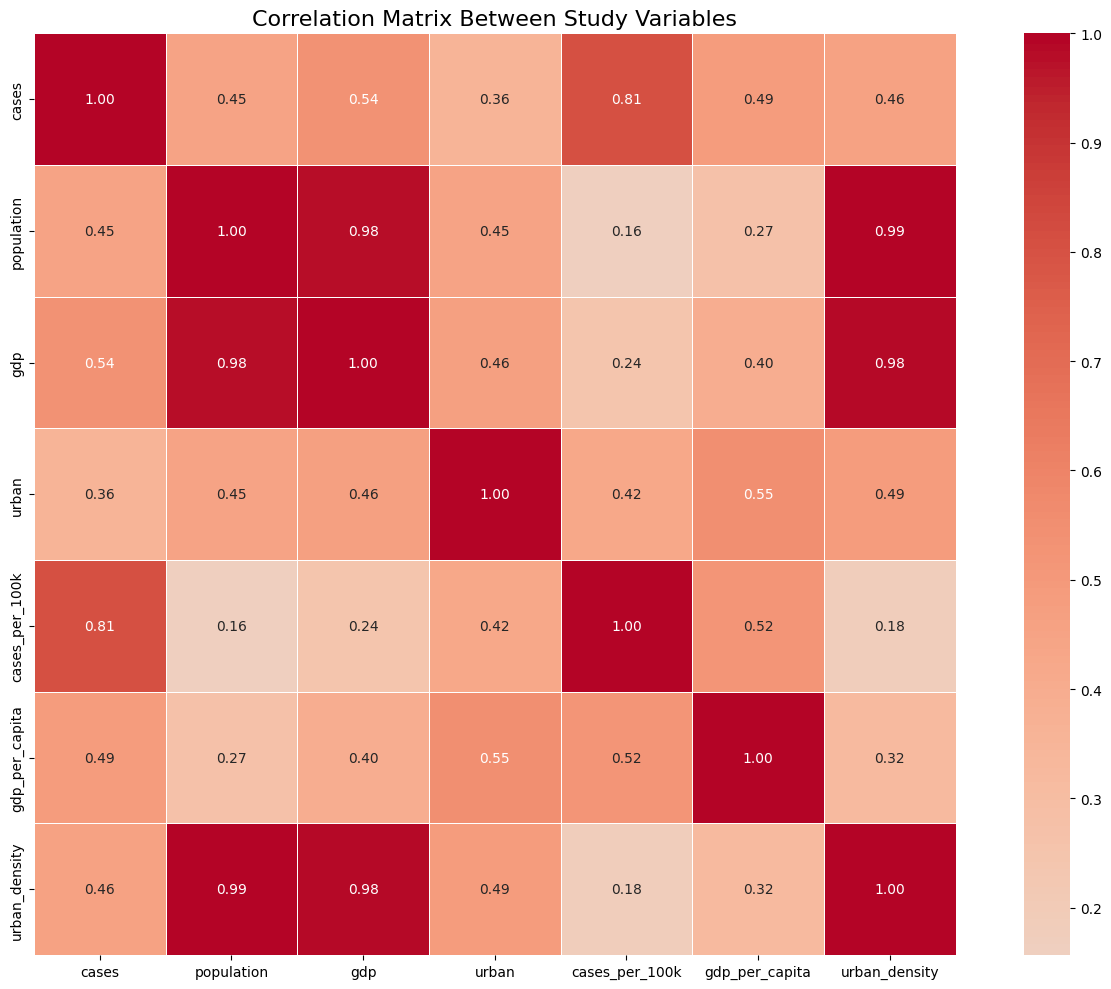

In [12]:
# Visualize correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix Between Study Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# Correlation analysis between key variables
print("Correlation between case rate and other variables:")
print(f"Correlation with urban population percentage: {correlation_matrix.loc['cases_per_100k', 'urban']:.3f}")
print(f"Correlation with GDP per capita: {correlation_matrix.loc['cases_per_100k', 'gdp_per_capita']:.3f}")
print(f"Correlation with total population: {correlation_matrix.loc['cases_per_100k', 'population']:.3f}")
print(f"Correlation with urban density: {correlation_matrix.loc['cases_per_100k', 'urban_density']:.3f}")

Correlation between case rate and other variables:
Correlation with urban population percentage: 0.425
Correlation with GDP per capita: 0.519
Correlation with total population: 0.157
Correlation with urban density: 0.178


## Step 5: Relationship Between Case Rate and Urban Population

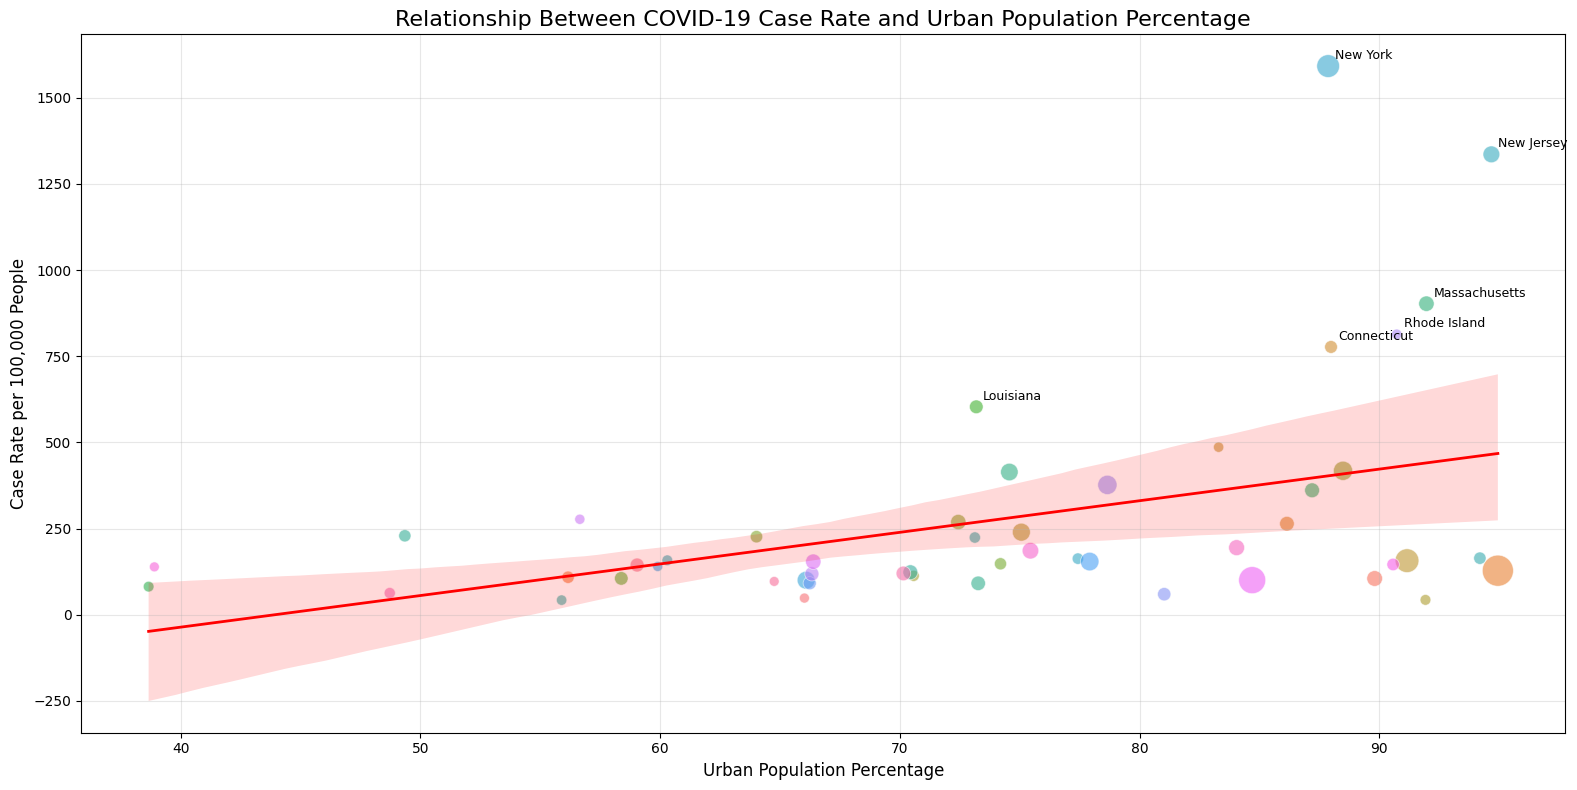

Pearson correlation coefficient: 0.425
P-value: 0.00212


In [16]:
# Examine relationship between case rate and urban population percentage
plt.figure(figsize=(16, 8))
scatter = sns.scatterplot(data=df, x='urban', y='cases_per_100k', size='population',
                          sizes=(50, 500), alpha=0.6, hue='state', legend=False)

# Add regression line
sns.regplot(data=df, x='urban', y='cases_per_100k', scatter=False, color='red',
            line_kws={'linewidth': 2})

# Add state labels for outliers
for idx, row in df.iterrows():
    if row['cases_per_100k'] > df['cases_per_100k'].mean() + df['cases_per_100k'].std():
        plt.annotate(row['state'], (row['urban'], row['cases_per_100k']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Relationship Between COVID-19 Case Rate and Urban Population Percentage', fontsize=16)
plt.xlabel('Urban Population Percentage', fontsize=12)
plt.ylabel('Case Rate per 100,000 People', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = stats.pearsonr(df['urban'], df['cases_per_100k'])
print(f"Pearson correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.5f}")

## Step 6: Relationship Between Case Rate and GDP per Capita

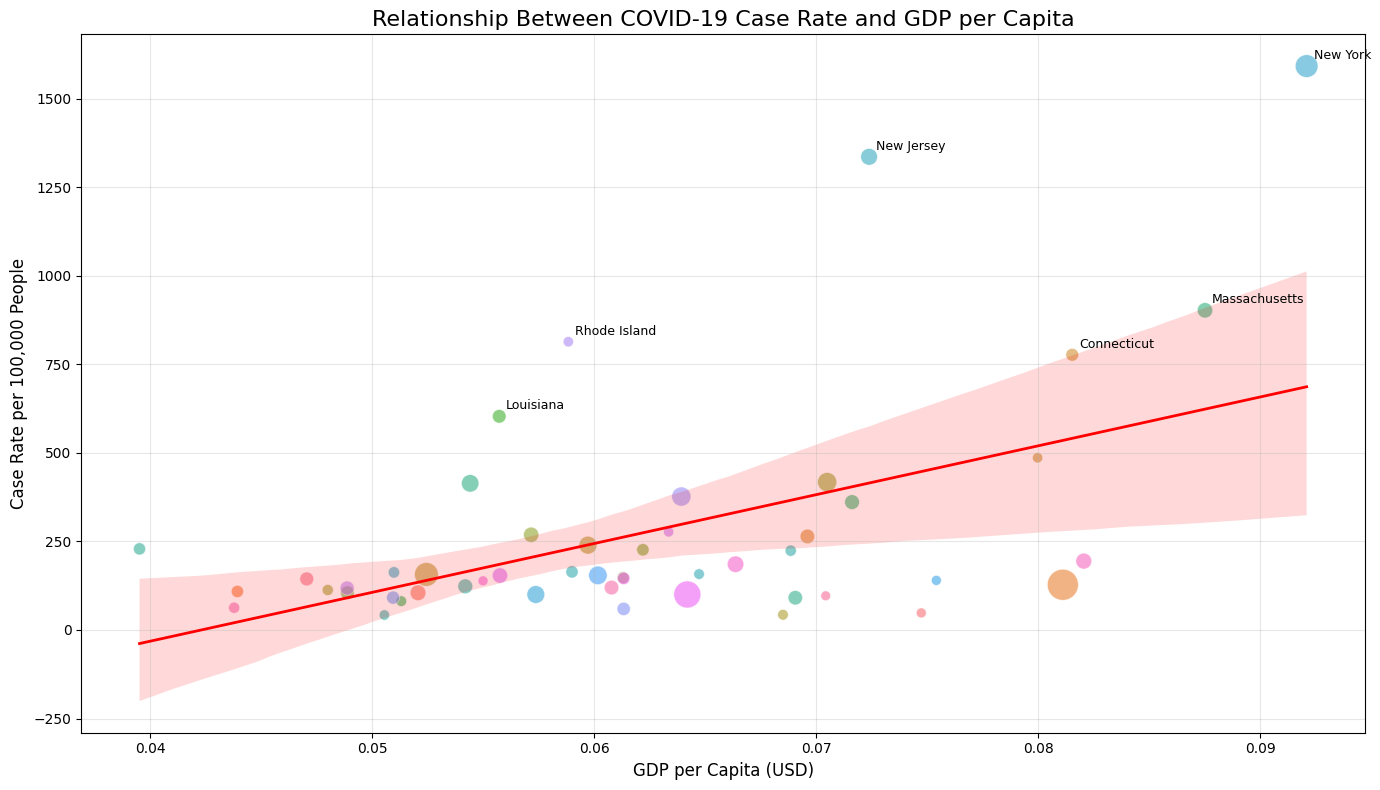

Pearson correlation coefficient: 0.519
P-value: 0.00011


In [17]:
# Examine relationship between case rate and GDP per capita
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(data=df, x='gdp_per_capita', y='cases_per_100k', size='population',
                          sizes=(50, 500), alpha=0.6, hue='state', legend=False)

# Add regression line
sns.regplot(data=df, x='gdp_per_capita', y='cases_per_100k', scatter=False, color='red',
            line_kws={'linewidth': 2})

# Add state labels for outliers
for idx, row in df.iterrows():
    if row['cases_per_100k'] > df['cases_per_100k'].mean() + df['cases_per_100k'].std():
        plt.annotate(row['state'], (row['gdp_per_capita'], row['cases_per_100k']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Relationship Between COVID-19 Case Rate and GDP per Capita', fontsize=16)
plt.xlabel('GDP per Capita (USD)', fontsize=12)
plt.ylabel('Case Rate per 100,000 People', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = stats.pearsonr(df['gdp_per_capita'], df['cases_per_100k'])
print(f"Pearson correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.5f}")

## Step 7: Outlier Analysis

In [19]:
# Identify states with extremely high case rates (Outliers)
threshold = df['cases_per_100k'].mean() + 2 * df['cases_per_100k'].std()
outliers = df[df['cases_per_100k'] > threshold]

print(f"Outlier threshold: {threshold:.2f}")
print(f"Number of states with extremely high case rates: {len(outliers)}")
print("\nStates with extremely high case rates:")
outliers[['state', 'cases', 'population', 'cases_per_100k', 'urban', 'gdp_per_capita', 'urban_density']]

Outlier threshold: 901.10
Number of states with extremely high case rates: 3

States with extremely high case rates:


,state,cases,population,cases_per_100k,urban,gdp_per_capita,urban_density
20,Massachusetts,62205,6892503,902.50,91.97,0.09,6339035.01
29,New Jersey,118652,8882190,1335.84,94.68,0.07,8409657.49
31,New York,309696,19453561,1591.98,87.87,0.09,17093844.05


In [20]:
# Compare states with highest and lowest case rates
top_5 = df.nlargest(5, 'cases_per_100k')
bottom_5 = df.nsmallest(5, 'cases_per_100k')

print("Top 5 states with highest case rates:")
top_5[['state', 'cases_per_100k', 'urban', 'gdp_per_capita', 'urban_density']]

print("\nTop 5 states with lowest case rates:")
bottom_5[['state', 'cases_per_100k', 'urban', 'gdp_per_capita', 'urban_density']]

Top 5 states with highest case rates:

Top 5 states with lowest case rates:


,state,cases_per_100k,urban,gdp_per_capita,urban_density
25,Montana,42.29,55.89,0.05,597340.02
10,Hawaii,43.01,91.93,0.07,1301611.13
1,Alaska,48.25,66.02,0.07,482966.01
36,Oregon,59.51,81.03,0.06,3417632.29
47,West Virginia,62.83,48.72,0.04,873134.02


## Step 8: Population Analysis

In [25]:
# Compare high-population states with other states
median_population = df['population'].median()
high_population = df[df['population'] > median_population]
low_population = df[df['population'] <= median_population]

print("Comparison of high-population vs low-population states:")
print(f"Average case rate in high-population states: {high_population['cases_per_100k'].mean():.2f}")
print(f"Average case rate in low-population states: {low_population['cases_per_100k'].mean():.2f}")
print(f"Average urban percentage in high-population states: {high_population['urban'].mean():.2f}%")
print(f"Average urban percentage in low-population states: {low_population['urban'].mean():.2f}%")
print(f"Average urban density in high-population states: {high_population['urban_density'].mean():.2f}")
print(f"Average urban density in low-population states: {low_population['urban_density'].mean():.2f}")

Comparison of high-population vs low-population states:
Average case rate in high-population states: 346.01
Average case rate in low-population states: 197.69
Average urban percentage in high-population states: 79.20%
Average urban percentage in low-population states: 67.96%
Average urban density in high-population states: 9100483.08
Average urban density in low-population states: 1487048.85


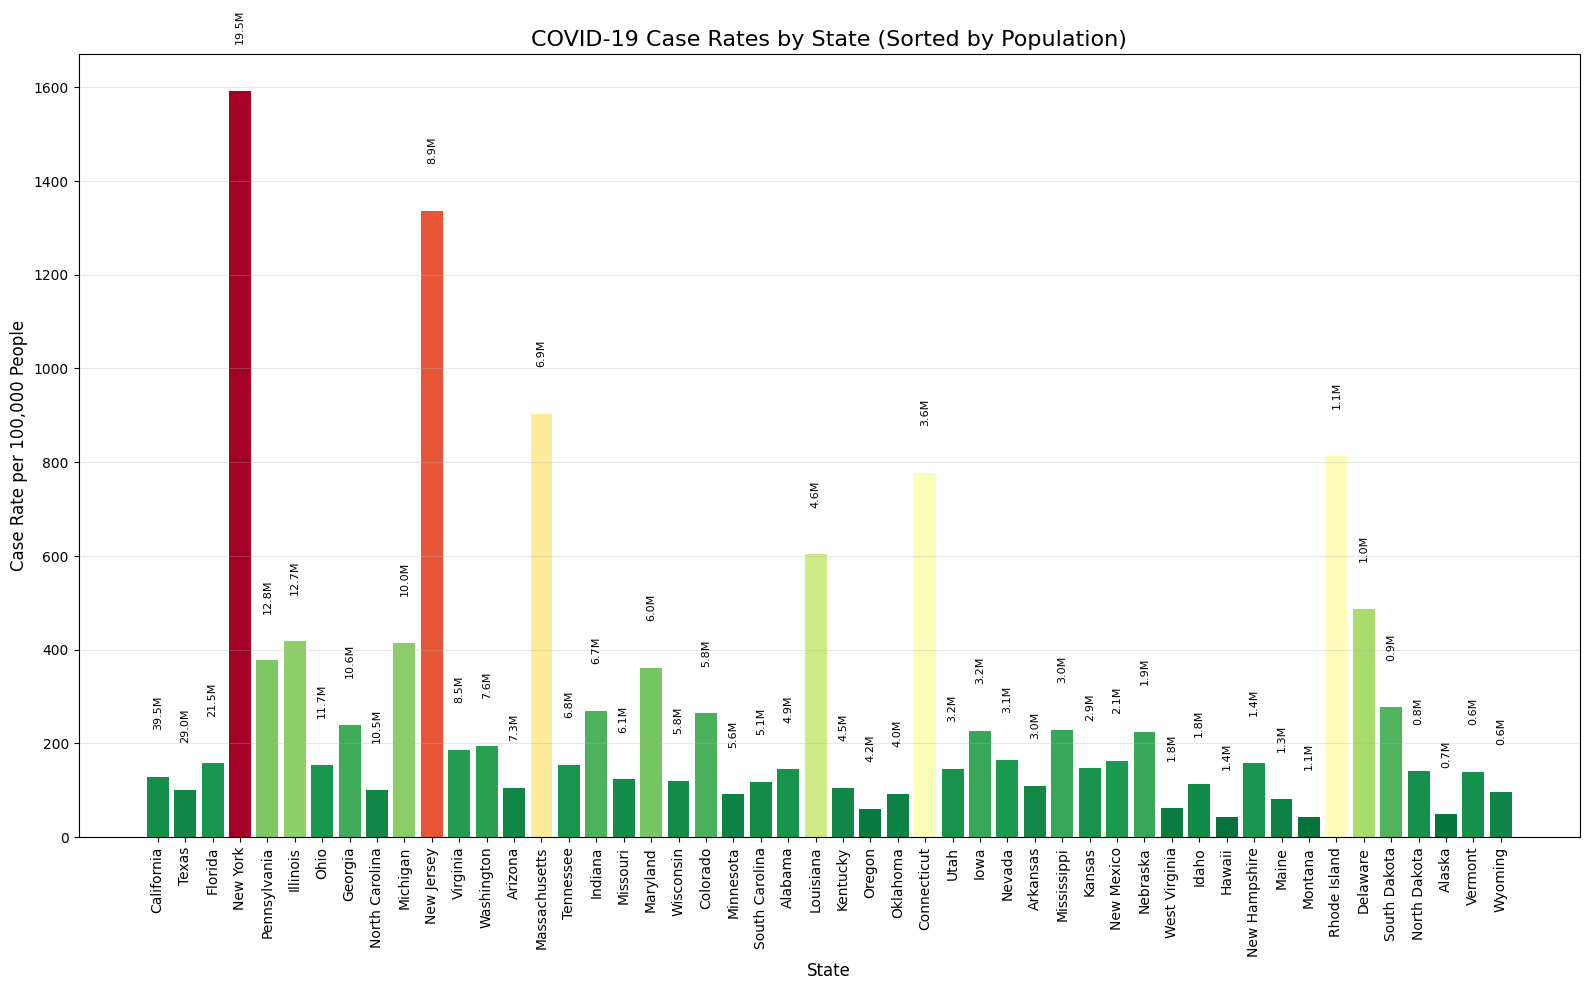

In [26]:
# Visualization of population comparison
plt.figure(figsize=(16, 10))

# Sort by population
df_sorted = df.sort_values('population', ascending=False)

# Create bar chart with gradient colors
bars = plt.bar(df_sorted['state'], df_sorted['cases_per_100k'],
               color=plt.cm.RdYlGn_r(df_sorted['cases_per_100k'] / df_sorted['cases_per_100k'].max()))

plt.title('COVID-19 Case Rates by State (Sorted by Population)', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Case Rate per 100,000 People', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3, axis='y')

# Add population labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{df_sorted.iloc[i]["population"]/1000000:.1f}M',
             ha='center', va='bottom', rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

# Step 9: Advanced Regression Modeling    😋